<a href="https://colab.research.google.com/github/ARehman007-max/internship/blob/main/task17_Prompt_Engineering_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

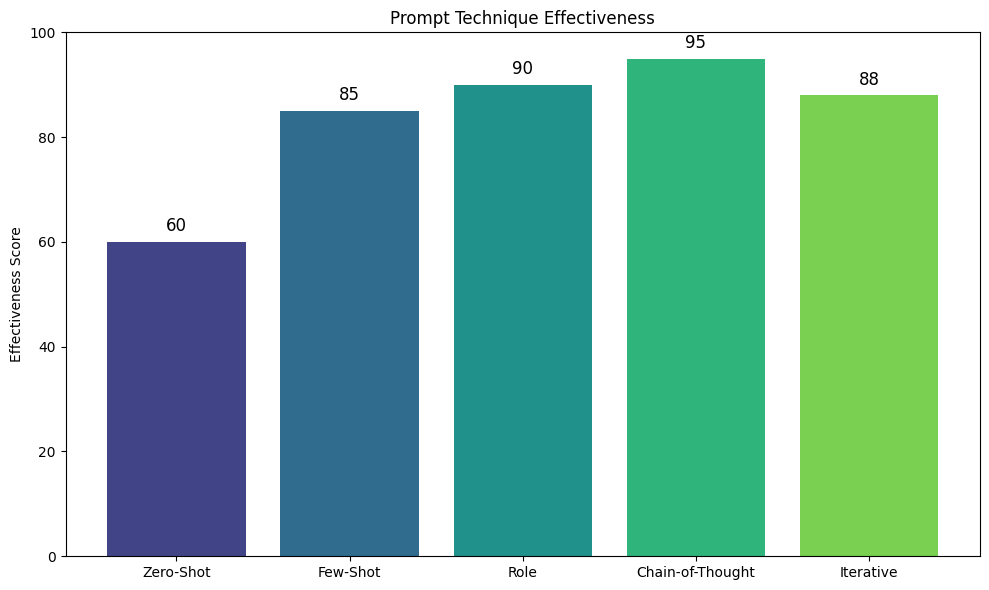

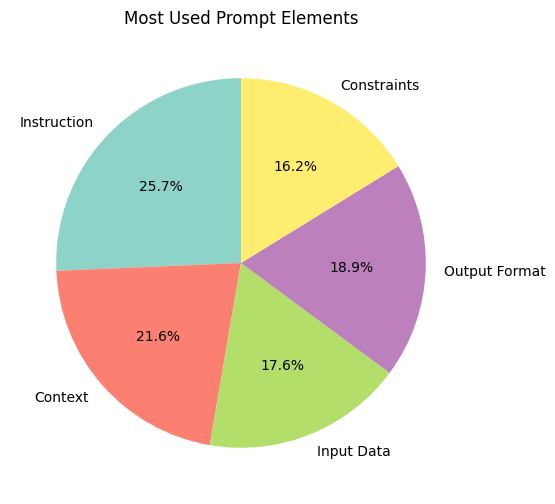

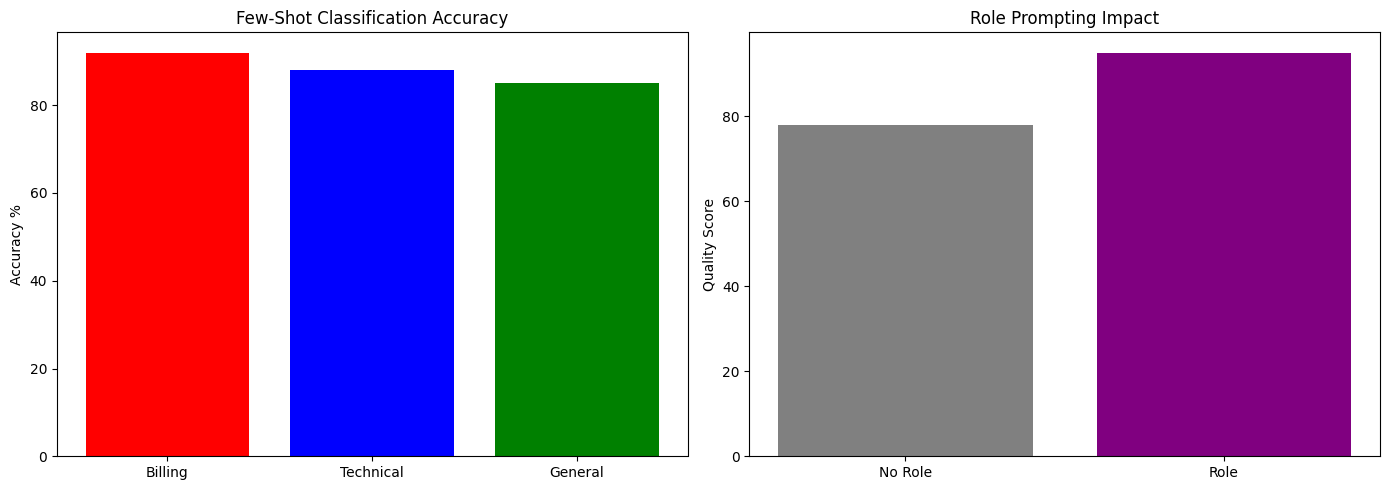

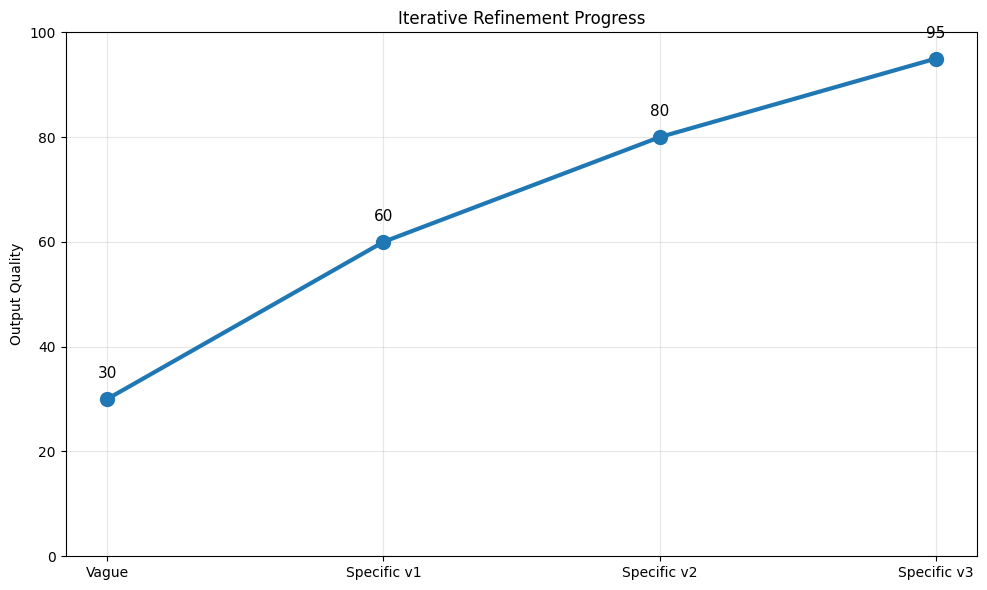

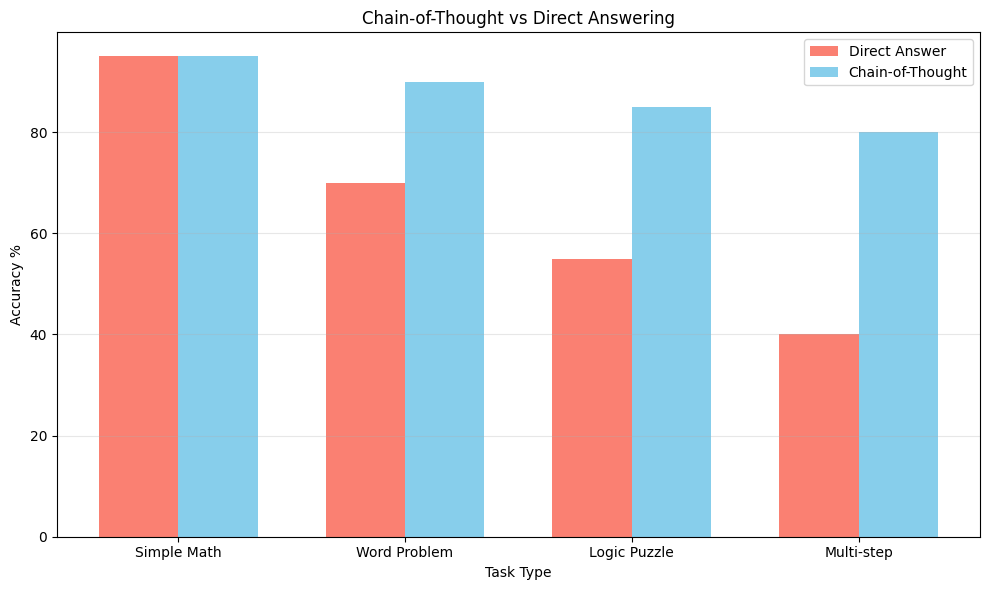

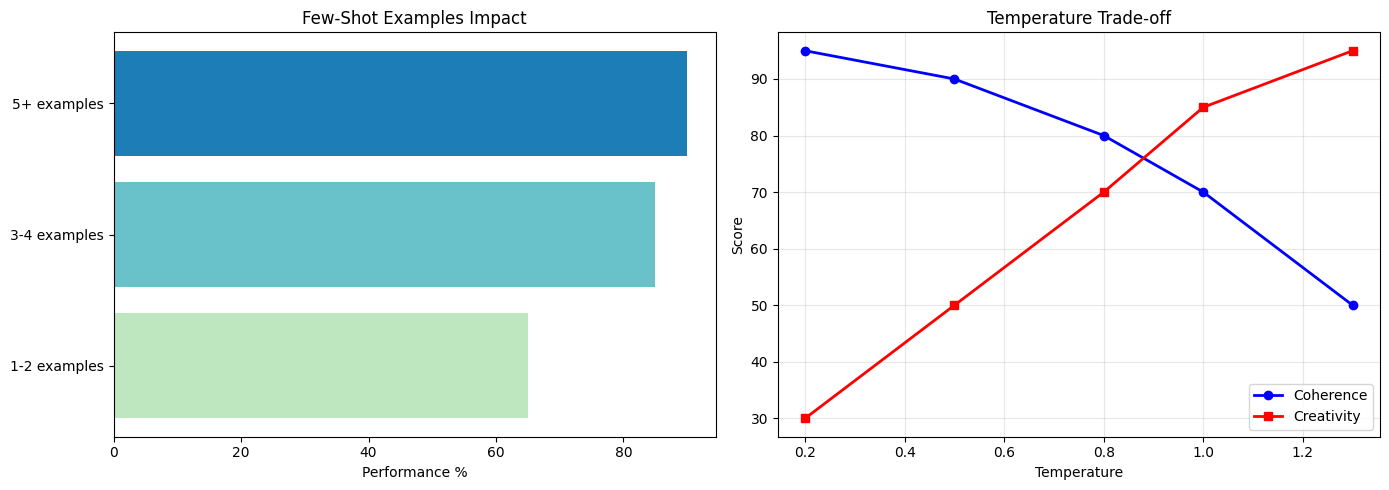

,Technique,Effectiveness,Ease of Use,Time Required,Consistency,ROI
0,Zero-Shot,60,95,10,50,6.000000
1,Few-Shot,85,70,30,85,2.833333
2,Role,90,80,20,75,4.500000
3,Chain-of-Thought,95,65,40,90,2.375000
4,Iterative,88,50,60,95,1.466667


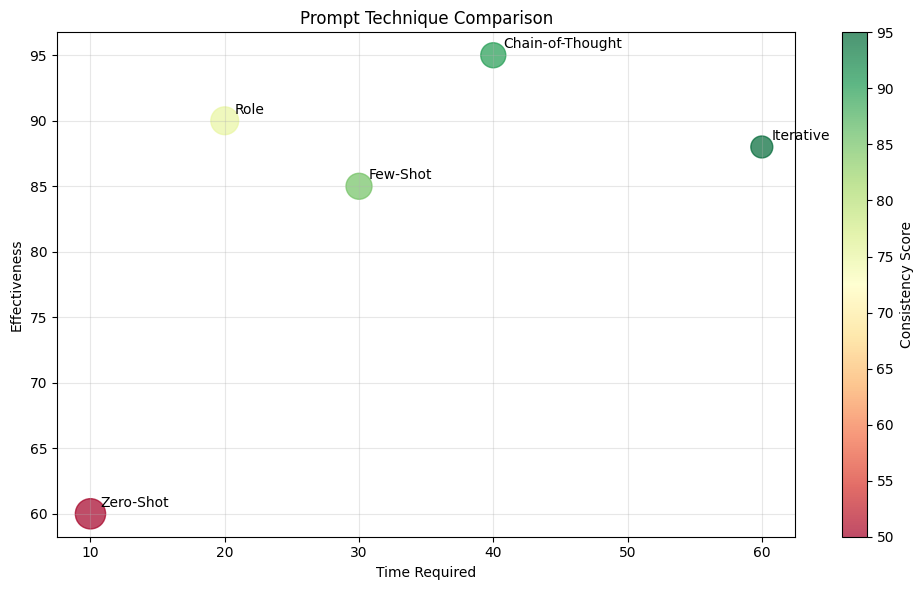

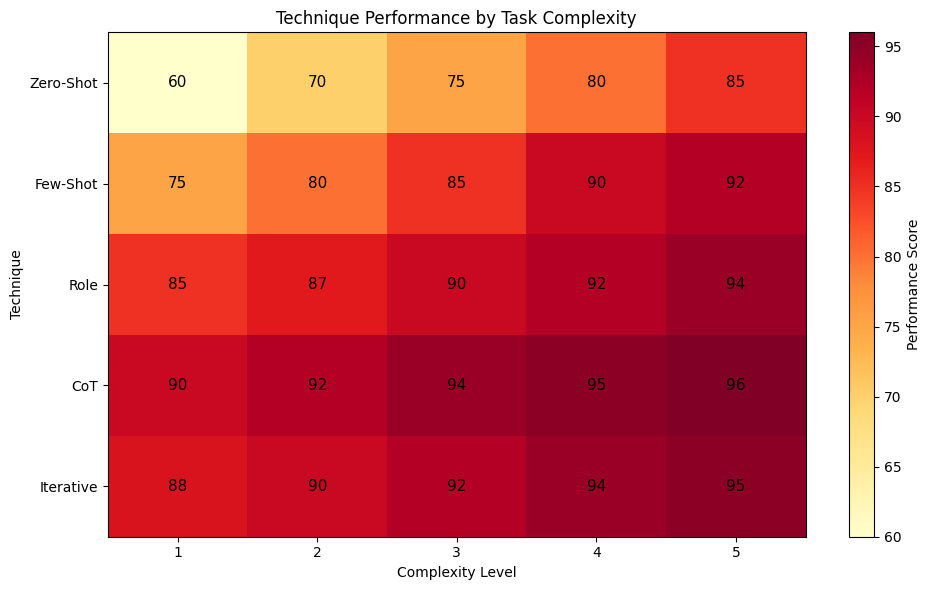

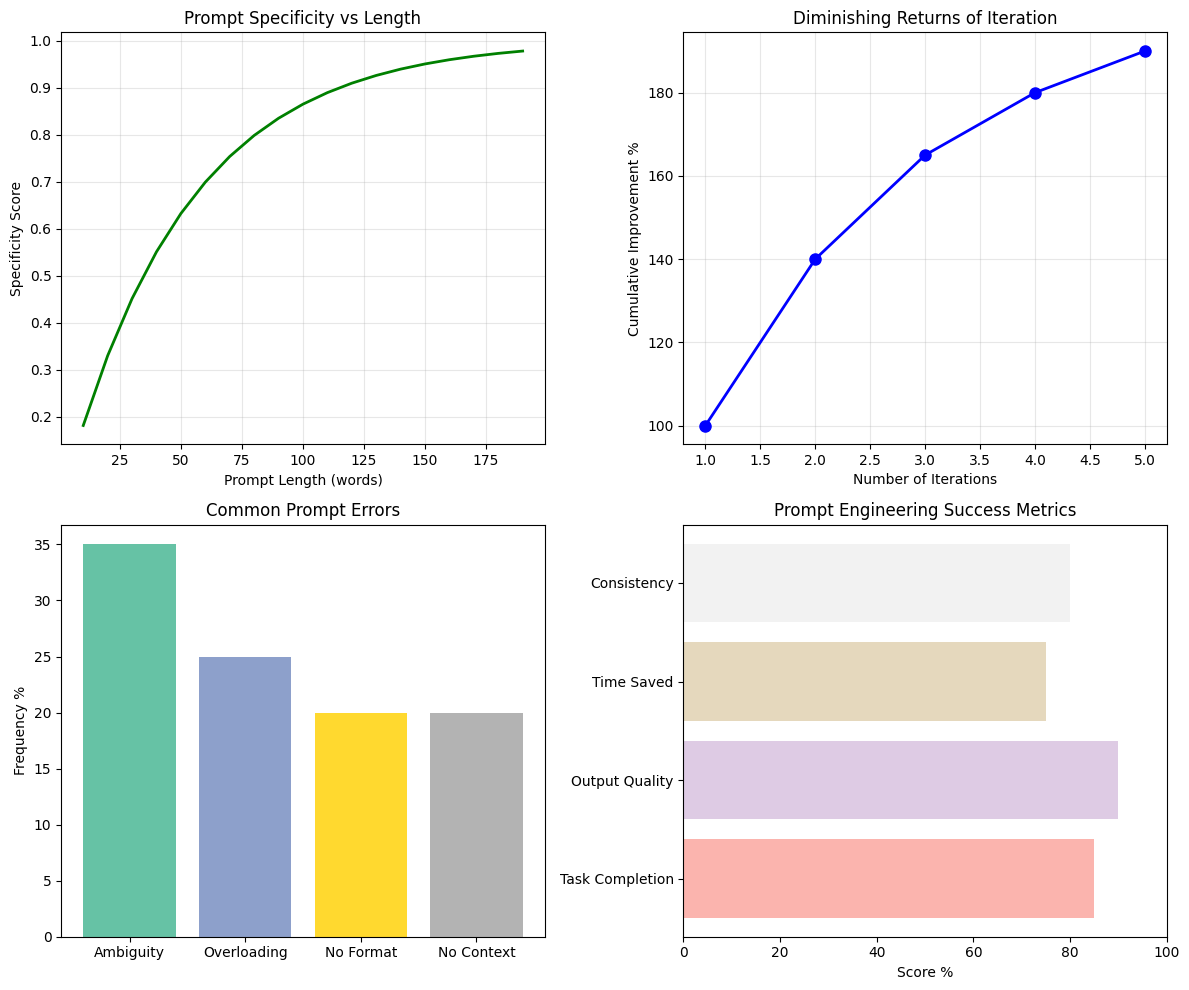

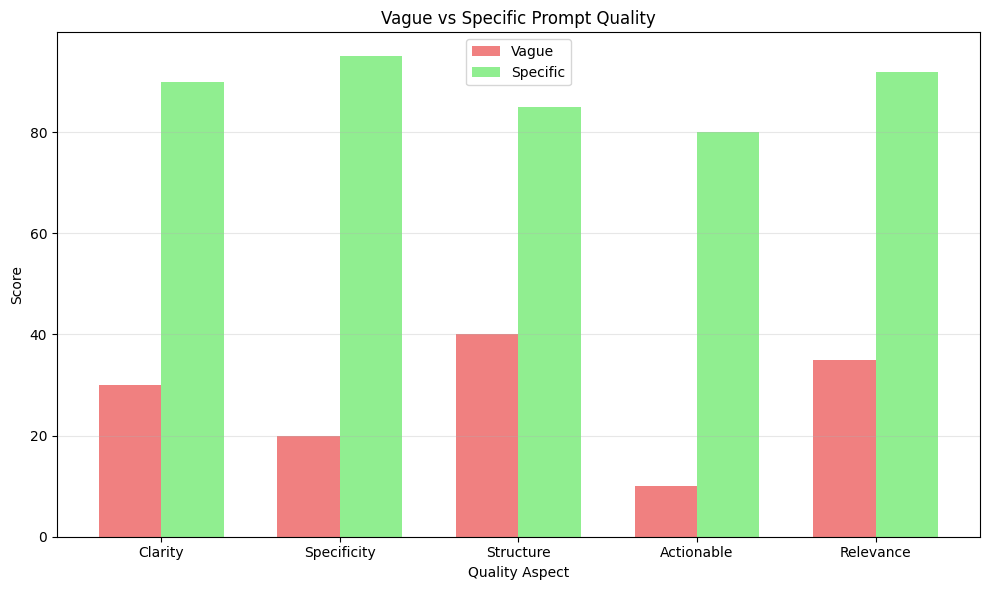

/tmp/ipykernel_832/2254214160.py:235: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['', '1', '2', '3', '4', '5'])
/tmp/ipykernel_832/2254214160.py:236: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['', 'Zero', 'Few', 'Role', 'CoT', 'Iter'])
/tmp/ipykernel_832/2254214160.py:239: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


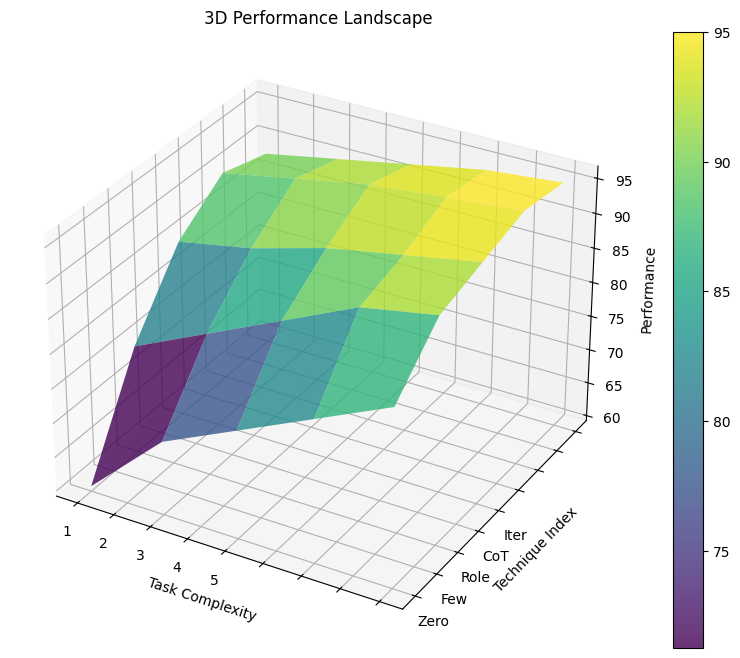

In [1]:
!pip install openai -q

import openai
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, HTML

prompt_techniques = ['Zero-Shot', 'Few-Shot', 'Role', 'Chain-of-Thought', 'Iterative']
effectiveness = [60, 85, 90, 95, 88]

plt.figure(figsize=(10, 6))
bars = plt.bar(prompt_techniques, effectiveness, color=plt.cm.viridis(np.linspace(0.2, 0.8, len(prompt_techniques))))
plt.title('Prompt Technique Effectiveness')
plt.ylabel('Effectiveness Score')
plt.ylim(0, 100)

for bar, value in zip(bars, effectiveness):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(value), ha='center', fontsize=12)

plt.tight_layout()
plt.show()

elements = ['Instruction', 'Context', 'Input Data', 'Output Format', 'Constraints']
present = [95, 80, 65, 70, 60]

plt.figure(figsize=(10, 6))
plt.pie(present, labels=elements, autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3(np.linspace(0, 1, len(elements))))
plt.title('Most Used Prompt Elements')
plt.show()

categories = ['Billing', 'Technical', 'General']
accuracy = [92, 88, 85, 78, 95, 90]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(categories, accuracy[:3], color=['red', 'blue', 'green'])
axes[0].set_title('Few-Shot Classification Accuracy')
axes[0].set_ylabel('Accuracy %')

axes[1].bar(['No Role', 'Role'], [accuracy[3], accuracy[4]], color=['gray', 'purple'])
axes[1].set_title('Role Prompting Impact')
axes[1].set_ylabel('Quality Score')

plt.tight_layout()
plt.show()

steps = ['Vague', 'Specific v1', 'Specific v2', 'Specific v3']
quality = [30, 60, 80, 95]

plt.figure(figsize=(10, 6))
plt.plot(steps, quality, marker='o', linewidth=3, markersize=10)
plt.title('Iterative Refinement Progress')
plt.ylabel('Output Quality')
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)

for i, (step, q) in enumerate(zip(steps, quality)):
    plt.annotate(f'{q}', (step, q), textcoords="offset points", xytext=(0, 15), ha='center', fontsize=11)

plt.tight_layout()
plt.show()

cot_tasks = ['Simple Math', 'Word Problem', 'Logic Puzzle', 'Multi-step']
direct = [95, 70, 55, 40]
cot = [95, 90, 85, 80]

x = np.arange(len(cot_tasks))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, direct, width, label='Direct Answer', color='salmon')
ax.bar(x + width/2, cot, width, label='Chain-of-Thought', color='skyblue')

ax.set_xlabel('Task Type')
ax.set_ylabel('Accuracy %')
ax.set_title('Chain-of-Thought vs Direct Answering')
ax.set_xticks(x)
ax.set_xticklabels(cot_tasks)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ranges = ['1-2 examples', '3-4 examples', '5+ examples']
few_shot_perf = [65, 85, 90]
axes[0].barh(ranges, few_shot_perf, color=plt.cm.GnBu(np.linspace(0.3, 0.8, 3)))
axes[0].set_xlabel('Performance %')
axes[0].set_title('Few-Shot Examples Impact')

temp_analysis = [0.2, 0.5, 0.8, 1.0, 1.3]
coherence = [95, 90, 80, 70, 50]
creativity = [30, 50, 70, 85, 95]

axes[1].plot(temp_analysis, coherence, 'b-o', label='Coherence', linewidth=2)
axes[1].plot(temp_analysis, creativity, 'r-s', label='Creativity', linewidth=2)
axes[1].set_xlabel('Temperature')
axes[1].set_ylabel('Score')
axes[1].set_title('Temperature Trade-off')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

data = {
    'Technique': ['Zero-Shot', 'Few-Shot', 'Role', 'Chain-of-Thought', 'Iterative'],
    'Effectiveness': [60, 85, 90, 95, 88],
    'Ease of Use': [95, 70, 80, 65, 50],
    'Time Required': [10, 30, 20, 40, 60],
    'Consistency': [50, 85, 75, 90, 95]
}

df = pd.DataFrame(data)
df['ROI'] = df['Effectiveness'] / df['Time Required']
display(df)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df['Time Required'], df['Effectiveness'], s=df['Ease of Use']*5, c=df['Consistency'], cmap='RdYlGn', alpha=0.7)

for i, row in df.iterrows():
    ax.annotate(row['Technique'], (row['Time Required'], row['Effectiveness']), xytext=(7, 5), textcoords='offset points')

ax.set_xlabel('Time Required')
ax.set_ylabel('Effectiveness')
ax.set_title('Prompt Technique Comparison')
plt.colorbar(scatter, label='Consistency Score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

matrix_data = np.array([
    [60, 70, 75, 80, 85],
    [75, 80, 85, 90, 92],
    [85, 87, 90, 92, 94],
    [90, 92, 94, 95, 96],
    [88, 90, 92, 94, 95]
])

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(matrix_data, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['1', '2', '3', '4', '5'])
ax.set_yticklabels(['Zero-Shot', 'Few-Shot', 'Role', 'CoT', 'Iterative'])
ax.set_xlabel('Complexity Level')
ax.set_ylabel('Technique')
ax.set_title('Technique Performance by Task Complexity')

for i in range(5):
    for j in range(5):
        ax.text(j, i, matrix_data[i][j], ha='center', va='center', fontsize=11)

plt.colorbar(im, label='Performance Score')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

prompt_length = np.arange(10, 200, 10)
specificity = 1 - np.exp(-prompt_length/50)

axes[0][0].plot(prompt_length, specificity, 'g-', linewidth=2)
axes[0][0].set_title('Prompt Specificity vs Length')
axes[0][0].set_xlabel('Prompt Length (words)')
axes[0][0].set_ylabel('Specificity Score')
axes[0][0].grid(True, alpha=0.3)

iterations = [1, 2, 3, 4, 5]
improvement = [100, 140, 165, 180, 190]
axes[0][1].plot(iterations, improvement, 'b-o', linewidth=2, markersize=8)
axes[0][1].set_title('Diminishing Returns of Iteration')
axes[0][1].set_xlabel('Number of Iterations')
axes[0][1].set_ylabel('Cumulative Improvement %')
axes[0][1].grid(True, alpha=0.3)

error_types = ['Ambiguity', 'Overloading', 'No Format', 'No Context']
error_freq = [35, 25, 20, 20]
axes[1][0].bar(error_types, error_freq, color=plt.cm.Set2(np.linspace(0, 1, 4)))
axes[1][0].set_title('Common Prompt Errors')
axes[1][0].set_ylabel('Frequency %')

success_metrics = ['Task Completion', 'Output Quality', 'Time Saved', 'Consistency']
metrics_values = [85, 90, 75, 80]
axes[1][1].barh(success_metrics, metrics_values, color=plt.cm.Pastel1(np.linspace(0, 1, 4)))
axes[1][1].set_title('Prompt Engineering Success Metrics')
axes[1][1].set_xlabel('Score %')
axes[1][1].set_xlim(0, 100)

plt.tight_layout()
plt.show()

comparison_data = pd.DataFrame({
    'Aspect': ['Clarity', 'Specificity', 'Structure', 'Actionable', 'Relevance'],
    'Vague Prompt': [30, 20, 40, 10, 35],
    'Specific Prompt': [90, 95, 85, 80, 92]
})

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_data['Aspect']))
width = 0.35

ax.bar(x - width/2, comparison_data['Vague Prompt'], width, label='Vague', color='lightcoral')
ax.bar(x + width/2, comparison_data['Specific Prompt'], width, label='Specific', color='lightgreen')

ax.set_xlabel('Quality Aspect')
ax.set_ylabel('Score')
ax.set_title('Vague vs Specific Prompt Quality')
ax.set_xticks(x)
ax.set_xticklabels(comparison_data['Aspect'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

x = np.arange(5)
y = np.arange(5)
X, Y = np.meshgrid(x, y)
Z = matrix_data

surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.8)
ax.set_xlabel('Task Complexity')
ax.set_ylabel('Technique Index')
ax.set_zlabel('Performance')
ax.set_title('3D Performance Landscape')

ax.set_xticklabels(['', '1', '2', '3', '4', '5'])
ax.set_yticklabels(['', 'Zero', 'Few', 'Role', 'CoT', 'Iter'])

plt.colorbar(surf)
plt.tight_layout()
plt.show()

